# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [ ]:
ПІБ = 'Потапова Світлана'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-31'      # напр. 'КН-31'
ВАРІАНТ = 16     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [ ]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 16 · Потапова Світлана, ШІ-31, «Друк-Сервіс»
Підприємство «Друк-Сервіс» виготовляє поліграфію. Одиниця виміру плану: тис. прим./тиждень.

                          Буклет  Каталог  Календар  Плакат  ЗАПАС
Крейдований папір, кг          1        6         4       2    412
Офсетний папір, кг             4        1         1       2   1005
Фарба, кг                      4        4         6       6    996
Друкарська машина, год         5        6         3       3    599
Різка й фальцювання, год       1        2         4       2    390

                    Буклет  Каталог  Календар  Плакат
Прибуток з одиниці      33       40        58      17

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Різка й фальцювання, год
  ціна:   8.2 за одиницю
  обсяг:  до 44 одиниць


In [ ]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення:
*   x1 - обсяг випуску буклетів
*   x2 - обсяг випуску каталогів
*   x3 - обсяг випуску календарів
*   x4 - обсяг випуску плакатів

Одиниця виміру плану: тис. прим./тиждень.


Цільова функція:

Z = 33\*x1 + 40\*x2 + 58\*x3 + 17\*x4 => max
(максимізувати прибуток)

Обмеження:

*   1\*x1 + 6\*x2 + 4\*x3 + 2\*x4 <= 412 (Крейдований папір)
*   4\*x1 + 1\*x2 + 1\*x3 + 2\*x4 <= 1005 (Офсетний папір)
*   4\*x1 + 4\*x2 + 6\*x3 + 6\*x4 <= 996 (Фарба)
*   5\*x1 + 6\*x2 + 3\*x3 + 3\*x4 <= 599 (Друкарська машина)
*   1\*x1 + 2\*x2 + 4\*x3 + 2\*x4 <= 390 (Різка й фальцювання)

Невід'ємність:

x1, x2, x3, x4 >= 0

### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:**

Запас ресурсу є параметром, бо це фіксоване обмеження задачі, яке ми не можемо змінити. Якби підприємство могло докуповувати ресурси, запас став би змінною рішення, у цільовій функції з'явилися б витрати на купівлю цих ресурсів, а у лівій частині обмежень з'явилися б нові змінні закупівлі зі знаком мінус (бо вони збільшують доступний ресурс)

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [ ]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [72.118, 0, 79.471, 0]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 6989.176             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [72.118, 0, 79.471, 0] | прибуток 6989.176


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [ ]:
# ВАШ КОД
import numpy as np
import pandas as pd
from scipy.optimize import linprog

c = -np.array([33, 40, 58, 17], float)

A = np.array([
    [1, 6, 4, 2],
    [4, 1, 1, 2],
    [4, 4, 6, 6],
    [5, 6, 3, 3],
    [1, 2, 4, 2]
], float)

b = np.array([412, 1005, 996, 599, 390], float)

bounds = [(0, None) for _ in range(4)]

res = linprog(c, A_ub=A, b_ub=b, bounds=bounds, method='highs')

план = res.x
прибуток = -res.fun

print("Оптимальний план (Буклет, Каталог, Календар, Плакат):", np.round(план, 3))
print("Максимальний прибуток:", round(прибуток, 3))

Оптимальний план (Буклет, Каталог, Календар, Плакат): [72.118  0.    79.471  0.   ]
Максимальний прибуток: 6989.176


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [ ]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Крейдований папір, кг | 390 | 0 | 412 | 1E+30 | 22 |
| Офсетний папір, кг | 367.94 | 0 | 1005 | 1E+30 | 637.06 |
| Фарба, кг | 765.29 | 0 | 996 | 1E+30 | 230.7 |
| Дркуарська машина, год | 599 | 4.35 | 599 | 392.2 | 306.5 |
| Різка й фальцювання, год | 390 | 11.24 | 390 | 22 | 270.2 |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**

У дефіциті ресурси "Друкарська машина" та "Різка й фальцювання", оскільки їх запаси були використані повністю (остаточне значення рівне правій стороні обмеження) та їхня тіньова ціна не є нульовою

У надлишку "Крейдований папір", "Офсетний папір" та "Фарба", оскільки їх тіньова ціна рівна нулю та було використано менше ресурсів ніж наявно у запасі


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
| Буклет | 72.118 | 0 | 33 | 63.67 | 8.11 |
| Каталог | 0 | -8.59 | 40 | 8.59 | 1E+30 |
| Календар | 79.471 | 0 | 58 | 74 | 36.5 |
| Плакат | 0 | -18.53 | 17 | 18.53 | 1E+30 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

Не виробляються вироби "Каталог" та "Плакат". Щоб вони увійшли в план, прибуток з одиниці цих виробів мав би зрости щонайменше на 8.59 та 18.53 грн відповідно. Ці числа взяті з стовпчиків "Допустиме збільшення" та "Зведена вартість"


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [ ]:
# ВАШ КОД
b_upd = np.array([412, 1005, 996, 599, 391], float)

res = linprog(c, A_ub=A, b_ub=b_upd, bounds=bounds, method='highs')

план_upd = res.x
прибуток_upd = -res.fun

print("Оптимальний план (Буклет, Каталог, Календар, Плакат):", np.round(план_upd, 3))
print("Максимальний прибуток:", round(прибуток_upd, 3))

print(f"Приріст прибутку: {round(прибуток_upd, 3)} - {round(прибуток, 3)} = {round(прибуток_upd-прибуток, 3)}" )

Оптимальний план (Буклет, Каталог, Календар, Плакат): [71.941  0.    79.765  0.   ]
Максимальний прибуток: 7000.412
Приріст прибутку: 7000.412 - 6989.176 = 11.235


**Відповідь 5.1:** *(приріст прибутку = ..., тіньова ціна зі звіту = ..., збігаються?)*

Збільшили запас "Різка й фальцювання" на 1:

Приріст прибутку = 11.235

Тіньова ціна зі звіту = 11.235

Числа збігаються, отже, при збільшенні дефіцитного запасу на одиницю, ми справді отримуємо приріст прибутку рівний тіньовій ціні

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

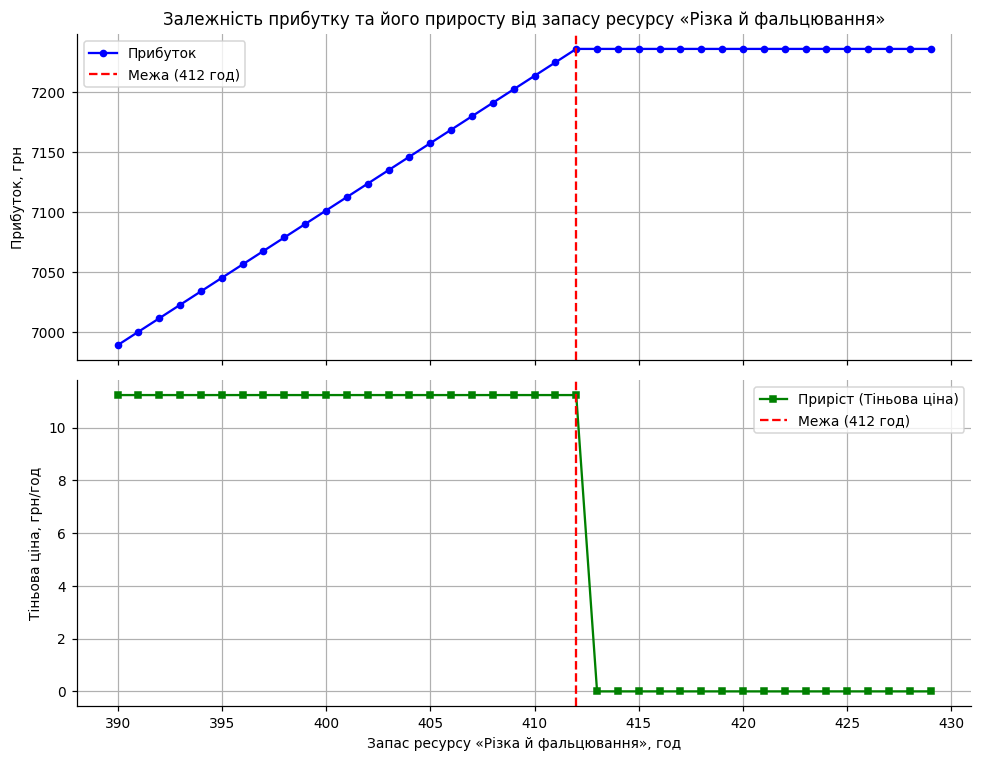

In [ ]:
# ВАШ КОД
base_supply = 390
supplies = np.arange(base_supply, 430, 1)
profits = []

for s in supplies:
    b_temp = np.array([412, 1005, 996, 599, s], float)
    res_temp = linprog(c, A_ub=A, b_ub=b_temp, bounds=bounds, method='highs')
    profits.append(-res_temp.fun)

profits = np.array(profits)

shadow_prices = np.diff(profits)
shadow_prices = np.insert(shadow_prices, 0, shadow_prices[0])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

ax1.plot(supplies, profits, 'b-o', markersize=4, label='Прибуток')
ax1.axvline(x=412, color='red', linestyle='--', label='Межа (412 год)')
ax1.set_ylabel('Прибуток, грн')
ax1.set_title('Залежність прибутку та його приросту від запасу ресурсу «Різка й фальцювання»')
ax1.grid(True)
ax1.legend()

ax2.plot(supplies, shadow_prices, 'g-s', markersize=4, label='Приріст (Тіньова ціна)')
ax2.axvline(x=412, color='red', linestyle='--', label='Межа (412 год)')
ax2.set_xlabel('Запас ресурсу «Різка й фальцювання», год')
ax2.set_ylabel('Тіньова ціна, грн/год')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

**Відповідь 5.2:** *(на скільки одиниць можна збільшити запас, доки тіньова ціна не зміниться;
чи збігається знайдена межа з «допустимим збільшенням» зі звіту Excel)*

Графік підтверджує "Допустиме збільшення" зі звіту Excel: ми можемо збільшити запас "Різка й фальцювання" на 22 години (з 390 до 412), після чого тіньова ціна впаде до 0, бо ресурс перестає бути дефіцитним, і збільшення запасу не підвищить прибуток (за поточних обмежень на інші ресурси)

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [ ]:
# ВАШ КОД

supplier_price = 8.2
optimal_buy = 22

shadow_price = 11.23529412
inc_revenue_analytic = optimal_buy * shadow_price
purchase_cost = optimal_buy * supplier_price
net_gain_analytic = inc_revenue_analytic - purchase_cost

b_new = np.array([412, 1005, 996, 599, 390 + optimal_buy], float)
res_new = linprog(c, A_ub=A, b_ub=b_new, bounds=bounds, method='highs')

new_profit_gross = -res_new.fun
base_profit = прибуток
real_inc_revenue = new_profit_gross - base_profit
net_gain_direct = real_inc_revenue - purchase_cost

print(f"Початковий прибуток: {base_profit:.3f} грн")
print(f"Додатковий прибуток (при +22 год): {inc_revenue_analytic:.3f} грн")
print(f"Новий загальний прибуток (при +22 год): {new_profit_gross:.3f} грн")
print(f"Витрати на закупівлю (22 год * 8.2 грн): {purchase_cost:.2f} грн")
print(f"Чистий виграш (аналітично): {net_gain_analytic:.2f} грн")
print(f"Чистий виграш (прямим розв'язком): {net_gain_direct:.2f} грн")

Початковий прибуток: 6989.176 грн
Додатковий прибуток (при +22 год): 247.176 грн
Новий загальний прибуток (при +22 год): 7236.353 грн
Витрати на закупівлю (22 год * 8.2 грн): 180.40 грн
Чистий виграш (аналітично): 66.78 грн
Чистий виграш (прямим розв'язком): 66.78 грн


**Відповідь 6.1:**
Постачальник пропонує до 44 одиниць ресурсу "Різка й фальцювання" за 8.2 грн/год

* Брати чи ні і чому:

Брати, бо ціна пропозиції (8.2 грн) менша за тіньову ціну ресурсу (11.24 грн), тому за кожну куплену годину буде прибуток 11.24-8.2=3.04 грн, що є вигідно

* Скільки одиниць має сенс купити і чому не більше:

Має сенс закупити 22 одиниці та не більше, бо, як відомо зі "Звіту про стійкість" та графіків з пункту 5.2, це є допустиме збільшення цього ресурсу, при подальшому збільшенні тіньова ціна падає до 0 і сенсу купляти ресурс немає

* Очікуваний виграш:

Додатковий прибуток = 22 год * 11.235 грн/год = 247.18 грн

Витрати на закупівлю = 22 год * 8.2 грн/год = 180.4 грн

Чистий виграш = 247.18 грн - 180.4 грн = 66.78 грн

* Перевірка прямим розв'язанням дала:
66.78 грн

---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [ ]:
# ВАШ КОД=

non_zero_vars = np.sum(план > 1e-5)

used_resources = A @ план
bound_constraints = np.sum(np.isclose(used_resources, b, atol=1e-5))

ненульових = int(non_zero_vars)
звязних = int(bound_constraints)

print(f"Ненульових змінних: {ненульових}")
print(f"Зв'язаних обмежень: {звязних}")


Ненульових змінних: 2
Зв'язаних обмежень: 2


In [ ]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** *(чи збіглися числа; що означала б розбіжність на практиці)*

Числа збіглися: кількість ненульових змінних дорівнює 2 ("Буклет" та "Календар"), кількість зв'язних обмежень теж дорівнює 2 ("Друкарська машина" та "Різка й фальцювання")

Якби кількість ненульових змінних була менша за кількість зв'язних обмежень, це свідчило би про виродженість розв'язку (коли одна з базових змінних дорівнює нулю), якщо ж кількість змінних була б більшою, це означало б наявність альтернативних оптимальних планів (когда є кілька різних комбінацій випуску, що дають один і той самий максимальний прибуток)

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [ ]:
# ВАШ КОД

plan_cont = план
profit_cont = прибуток
is_feasible_cont = True

plan_round = np.round(plan_cont)
used_round = A @ plan_round
is_feasible_round = bool(np.all(used_round <= b + 1e-5))
profit_round = float(-c @ plan_round)

res_int = linprog(c, A_ub=A, b_ub=b, bounds=bounds, integrality=1, method='highs')

plan_int = res_int.x
profit_int = -res_int.fun
is_feasible_int = res_int.success

print("1. Без цілочисельності:")
print(f"   План: {np.round(plan_cont, 3)}, Прибуток: {profit_cont:.3f}, Допустимий: {is_feasible_cont}")

print("\n2. Округлений план:")
print(f"   План: {plan_round.astype(int)}, Прибуток: {profit_round:.3f}, Допустимий: {is_feasible_round}")

print("\n3. Цілочисельний оптимум:")
print(f"   План: {plan_int.astype(int)}, Прибуток: {profit_int:.3f}, Допустимий: {is_feasible_int}")

1. Без цілочисельності:
   План: [72.118  0.    79.471  0.   ], Прибуток: 6989.176, Допустимий: True

2. Округлений план:
   План: [72  0 79  0], Прибуток: 6958.000, Допустимий: True

3. Цілочисельний оптимум:
   План: [70  2 79  0], Прибуток: 6972.000, Допустимий: True


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | [72.118, 0, 79.471, 0] | 6989.176 | Так |
| округлений | [72, 0, 79, 0] | 6958 | Так |
| цілочисельний оптимум | [72, 2, 79, 0] | 6972 | Так |

**Висновок:** *(чи можна округлювати і чому)*

Просте округлення не завжди є надійним методом: округлення у більшу сторону може призвести до недопустимого розв'язку (перевищення ліміту одного з дефіцитних ресурсів), а округлення у меншу сторону гарантує допустимість, але може втратити оптимальність (дати менший прибуток, ніж справжній цілочисельний оптимум).

На прикладі нашого плану: просте округлення нецілочисельного плану до найближчих цілих чисел ([72, 0, 79, 0]) дало допустимий розв'язок із прибутком 6958 грн. Проте справжній цілочисельний оптимум знайшов іншу комбінацію ([70, 2, 79, 0]), яка дає вищий прибуток (6972 грн)


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [ ]:
# ВАШ КОД — впишіть свої дані
постачальники = ['Полтава', 'Одеса', 'Тернопіль']           # напр. ['Шостка', 'Енергодар', 'Вінниця']
споживачі     = ['Суми', 'Вінниця', 'Івано-Франківськ', 'Трускавець']           # напр. ['Тернопіль', 'Афанасіївка', 'Рівне', 'Апостолове']
D = np.array([                    # матриця відстаней 3 x 4, км
    [174, 608, 945, 973],
    [803, 425, 797, 857],
    [822, 237, 133, 188]
])
запас = [40, 35, 25]                   # 3 числа
попит = [20, 30, 25, 25]                   # 4 числа

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Суми,Вінниця,Івано-Франківськ,Трускавець
Полтава,174,608,945,973
Одеса,803,425,797,857
Тернопіль,822,237,133,188


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [ ]:
# ВАШ КОД — розв'язок 1
prob = pulp.LpProblem("Transportation_Problem", pulp.LpMinimize)

suppliers_idx = range(len(постачальники))
consumers_idx = range(len(споживачі))

x = pulp.LpVariable.dicts("x", ((i, j) for i in suppliers_idx for j in consumers_idx), lowBound=0, cat='Continuous')

prob += pulp.lpSum(D[i][j] * x[i, j] for i in suppliers_idx for j in consumers_idx)

for i in suppliers_idx:
    prob += pulp.lpSum(x[i, j] for j in consumers_idx) == запас[i], f"Supply_{i}"

for j in consumers_idx:
    prob += pulp.lpSum(x[i, j] for i in suppliers_idx) == попит[j], f"Demand_{j}"

prob.solve(pulp.PULP_CBC_CMD(msg=0))

print(f"Статус розв'язку PuLP: {pulp.LpStatus[prob.status]}")
print(f"Сумарна вартість (транспортна робота): {pulp.value(prob.objective):.2f} км")

plan_matrix = np.zeros((len(постачальники), len(споживачі)))
for i in suppliers_idx:
    for j in consumers_idx:
        plan_matrix[i, j] = x[i, j].varValue

print("\nОптимальний план перевезень:")
display(pd.DataFrame(plan_matrix, index=постачальники, columns=споживачі))

shadow_prices_supply_list = [prob.constraints[f"Supply_{i}"].pi for i in suppliers_idx]
shadow_prices_demand_list = [prob.constraints[f"Demand_{j}"].pi for j in consumers_idx]
shadow_prices_all_pulp = shadow_prices_supply_list + shadow_prices_demand_list

print("\nТіньові ціни:")
for idx, name in enumerate(постачальники):
    print(f"  Постачальник {name}: {shadow_prices_supply_list[idx]:.4f}")
for idx, name in enumerate(споживачі):
    print(f"  Споживач {name}: {shadow_prices_demand_list[idx]:.4f}")

Статус розв'язку PuLP: Optimal
Сумарна вартість (транспортна робота): 43275.00 км

Оптимальний план перевезень:


,Суми,Вінниця,Івано-Франківськ,Трускавець
Полтава,20.0,0.0,0.0,20.0
Одеса,0.0,30.0,5.0,0.0
Тернопіль,0.0,0.0,20.0,5.0



Тіньові ціни:
  Постачальник Полтава: 546.0000
  Постачальник Одеса: 425.0000
  Постачальник Тернопіль: -239.0000
  Споживач Суми: -372.0000
  Споживач Вінниця: 0.0000
  Споживач Івано-Франківськ: 372.0000
  Споживач Трускавець: 427.0000


In [ ]:
# ВАШ КОД — розв'язок 2

c_flat = D.flatten()

m, n = D.shape

A_supply = np.zeros((m, m * n))
for i in range(m):
    for j in range(n):
        A_supply[i, i * n + j] = 1
b_supply = np.array(запас)

A_demand = np.zeros((n, m * n))
for j in range(n):
    for i in range(m):
        A_demand[j, i * n + j] = 1
b_demand = np.array(попит)

A_eq = np.vstack([A_supply, A_demand])
b_eq = np.concatenate([b_supply, b_demand])

bounds = [(0, None) for _ in range(m * n)]

res = linprog(c_flat, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print(f"Статус розв'язку SciPy: {res.message}")
print(f"Сумарна вартість (транспортна робота): {res.fun:.2f} км")

scipy_plan = res.x.reshape((m, n))
print("\nОптимальний план перевезень:")
display(pd.DataFrame(scipy_plan, index=постачальники, columns=споживачі))

marginals = res.eqlin.marginals if hasattr(res, 'eqlin') else res.get('ineqlin', None)
if hasattr(res, 'eqlin'):
    shadow_prices_all = res.eqlin.marginals
else:
    shadow_prices_all = res.get('marginals', np.zeros(len(b_eq)))

print("\nТіньові ціни:")
for idx, name in enumerate(постачальники):
    print(f"  Постачальник {name}: {shadow_prices_all[idx]:.4f}")
for idx, name in enumerate(споживачі):
    print(f"  Споживач {name}: {shadow_prices_all[m + idx]:.4f}")

Статус розв'язку SciPy: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Сумарна вартість (транспортна робота): 43275.00 км

Оптимальний план перевезень:


,Суми,Вінниця,Івано-Франківськ,Трускавець
Полтава,20.0,0.0,0.0,20.0
Одеса,0.0,30.0,5.0,0.0
Тернопіль,0.0,0.0,20.0,5.0



Тіньові ціни:
  Постачальник Полтава: -0.0000
  Постачальник Одеса: -121.0000
  Постачальник Тернопіль: -785.0000
  Споживач Суми: 174.0000
  Споживач Вінниця: 546.0000
  Споживач Івано-Франківськ: 918.0000
  Споживач Трускавець: 973.0000


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [ ]:
# ВАШ КОД — порівняння
sp_pulp = [c.pi for c in prob.constraints.values()]
sp_scipy = shadow_prices_all

names = постачальники + споживачі
diff = np.array(sp_pulp) - np.array(sp_scipy)

df_comp = pd.DataFrame({
    'PuLP': sp_pulp,
    'SciPy': sp_scipy,
    'Різниця (PuLP - SciPy)': diff
}, index=names)

print(df_comp)
print("\nРізниця для постачальників:", diff[:3])
print("Різниця для споживачів:", diff[3:])

                   PuLP  SciPy  Різниця (PuLP - SciPy)
Полтава           546.0   -0.0                   546.0
Одеса             425.0 -121.0                   546.0
Тернопіль        -239.0 -785.0                   546.0
Суми             -372.0  174.0                  -546.0
Вінниця             0.0  546.0                  -546.0
Івано-Франківськ  372.0  918.0                  -546.0
Трускавець        427.0  973.0                  -546.0

Різниця для постачальників: [546. 546. 546.]
Різниця для споживачів: [-546. -546. -546. -546.]


**Відповідь 10.2:**

* Вартість у двох розв'язувачів:

Однакова і становить 43275 км
* Тіньові ціни збіглися чи ні:

Не збіглися
* Яку закономірність ви побачили в різниці:

Для всіх 3 постачальників тіньові ціни в PuLP більші на 546, ніж у SciPy, а для всіх 4 споживачів - менші на 546

* Що це означає для того, хто збирається ухвалювати рішення за цим звітом:

Абсолютні значення окремих тіньових цін постачальника чи споживача не є фіксованими самими по собі і залежать від вибору базової точки відліку (зсуву). Для ухвалення рішень мають значення тільки відносні різниці між потенціалами пунктів одного типу, що показує реальну економічну перевагу одного пункту над іншим


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [ ]:
# ВАШ КОД
non_zero_shipments = int(np.sum(plan_matrix > 1e-5))

binding_constraints = len(b_eq)

print(f"Кількість ненульових перевезень: {non_zero_shipments}")
print(f"Кількість зв'язних обмежень: {binding_constraints}")
print(f"Сума (m + n): {m} + {n} = {m + n}")
print(f"Теоретична кількість базових змінних (m + n - 1): {m + n - 1}")

Кількість ненульових перевезень: 6
Кількість зв'язних обмежень: 7
Сума (m + n): 3 + 4 = 7
Теоретична кількість базових змінних (m + n - 1): 6


**Відповідь 11.1:**

* Ненульових перевезень:
 6
* Зв'язних обмежень:
7
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження:

Тому що в класичній збалансованій транспортній задачі всі обмеження є рівностями: весь запас має бути повністю вивезений, а весь попит - повністю задоволений
* На скільки ненульових перевезень менше і чому саме на стільки:

У транспортній задачі одне з обмежень є лінійно залежним від інших, оскільки сумарний запас дорівнює сумарному попиту. Через цей баланс будь-які m+n-1 обмежень автоматично диктують виконання останнього m+n-го обмеження, і базис складається саме з m+n-1=3+4-1= 6 незалежних змінних (перевезень)


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

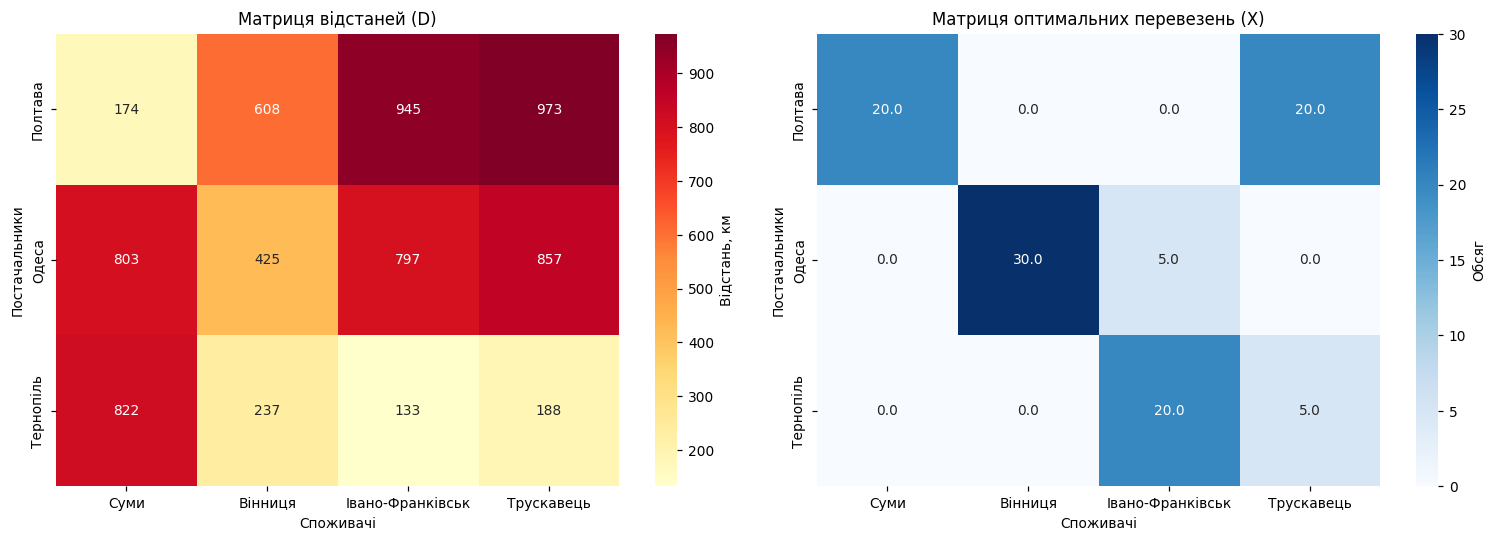

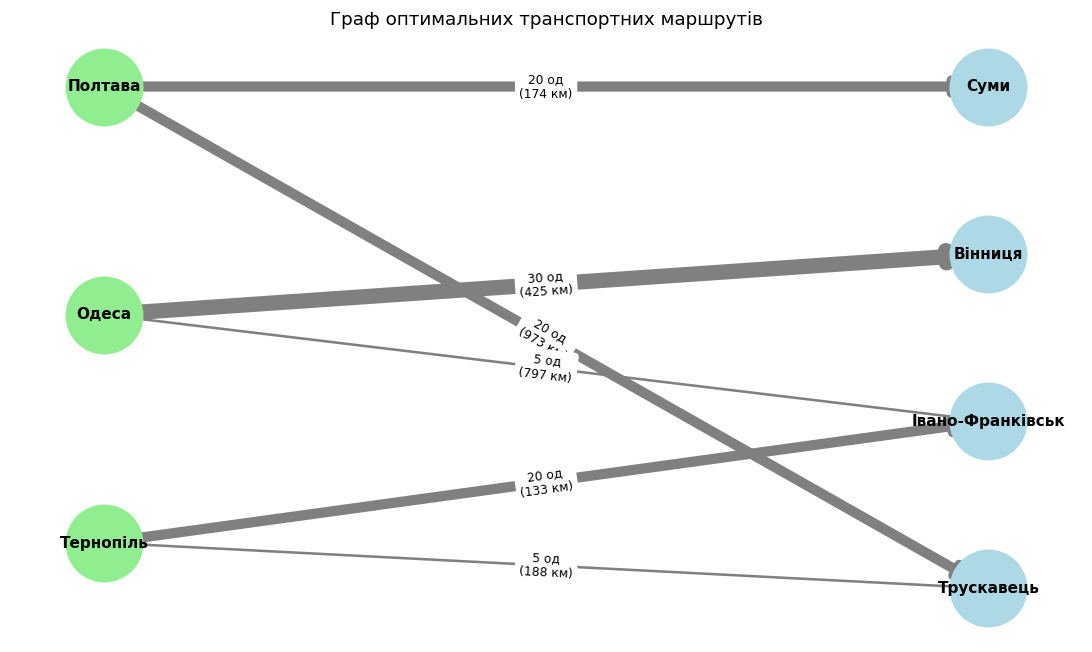

In [ ]:
# ВАШ КОД
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

df_dist = pd.DataFrame(D, index=постачальники, columns=споживачі)
df_plan = pd.DataFrame(plan_matrix, index=постачальники, columns=споживачі)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df_dist, annot=True, fmt=".0f", cmap="YlOrRd", ax=axes[0], cbar_kws={'label': 'Відстань, км'})
axes[0].set_title("Матриця відстаней (D)")
axes[0].set_xlabel("Споживачі")
axes[0].set_ylabel("Постачальники")

sns.heatmap(df_plan, annot=True, fmt=".1f", cmap="Blues", ax=axes[1], cbar_kws={'label': 'Обсяг'})
axes[1].set_title("Матриця оптимальних перевезень (X)")
axes[1].set_xlabel("Споживачі")
axes[1].set_ylabel("Постачальники")

plt.tight_layout()
plt.show()


G = nx.DiGraph()

for supp in постачальники:
    G.add_node(supp, bipartite=0)
for cons in споживачі:
    G.add_node(cons, bipartite=1)

pos = {}
for i, supp in enumerate(постачальники):
    pos[supp] = np.array([0, -i * 1.5])
for j, cons in enumerate(споживачі):
    pos[cons] = np.array([1, -j * 1.1])

edge_widths = []
edge_labels = {}

for i, supp in enumerate(постачальники):
    for j, cons in enumerate(споживачі):
        val = plan_matrix[i, j]
        if val > 1e-5:
            G.add_edge(supp, cons, weight=val)
            edge_widths.append(val / 3)
            edge_labels[(supp, cons)] = f"{val:.0f} од\n({D[i,j]:.0f} км)"

plt.figure(figsize=(10, 6))
nx.draw_networkx_nodes(G, pos, nodelist=постачальники, node_color='lightgreen', node_size=2500)
nx.draw_networkx_nodes(G, pos, nodelist=споживачі, node_color='lightblue', node_size=2500)

nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='gray', arrowsize=20)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

plt.title("Граф оптимальних транспортних маршрутів", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

**Висновок:** *(одне речення про те, що видно на теплових картах)*

Теплові карти  показують, що алгоритм максимізує перевезення за найкоротшими маршрутами (жовті комірки відстаней відповідають синім коміркам обсягів), а далекі маршрути (Полтав - Трускавець, Одеса - Івано-Франківськ) задіяно вимушено для повного покриття залишку попиту в умовах обмежених запасів ближчих постачальників

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [ ]:
ІНСТРУМЕНТИ_ШІ = 'Gemini'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'синтаксис',
    'етапи 4–5, читання та перевірка звіту': 'синтаксис',
    'етап 6, рішення про закупівлю':        'ні',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'код був згенерований ШІ для графіків у 5.2, теплових мап у 11.2, для перевірки цілочисельності у 8.1, та для розвязання транспортної задачі у 10.1 '

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Потапова Світлана
інструменти:                               Gemini
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     синтаксис
етапи 4–5, читання та перевірка звіту:     синтаксис
етап 6, рішення про закупівлю:             ні
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
код був згенерований ШІ для графіків у 5.2, теплових мап у 11.2, для перевірки цілочисельності у 8.1, та для розвязання транспортної задачі у 10.1 


---
# Крок 13. Фінальна самоперевірка

In [ ]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
